# Блок 3. Задача 2: k-means и k-means++

Цель: сравнить обычную случайную инициализацию центроидов и инициализацию `k-means++` на датасете `Iris`.

Используется алгоритм `KMeans`.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [12]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris["target_name"] = df_iris["target"].map(dict(enumerate(iris.target_names)))
feature_cols = iris.feature_names

display(df_iris.head())
print("Размер датасета:", df_iris.shape)
print("Истинное распределение классов:")
print(df_iris["target_name"].value_counts())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Размер датасета: (150, 6)
Истинное распределение классов:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Подготовка данных


In [13]:
X = df_iris[feature_cols]
y_true = df_iris["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)


## Обучение моделей


In [14]:
from sklearn.cluster import KMeans

kmeans_random = KMeans(n_clusters=3, init="random", n_init=10, random_state=42)
labels_random = kmeans_random.fit_predict(X_scaled)

kmeans_plus = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
labels_plus = kmeans_plus.fit_predict(X_scaled)

print("Inertia k-means:", round(kmeans_random.inertia_, 3))
print("Inertia k-means++:", round(kmeans_plus.inertia_, 3))


Inertia k-means: 139.825
Inertia k-means++: 139.82


## Метрики и визуализация


k-means
Количество кластеров: 3
Adjusted Rand Index: 0.61
Silhouette score: 0.459


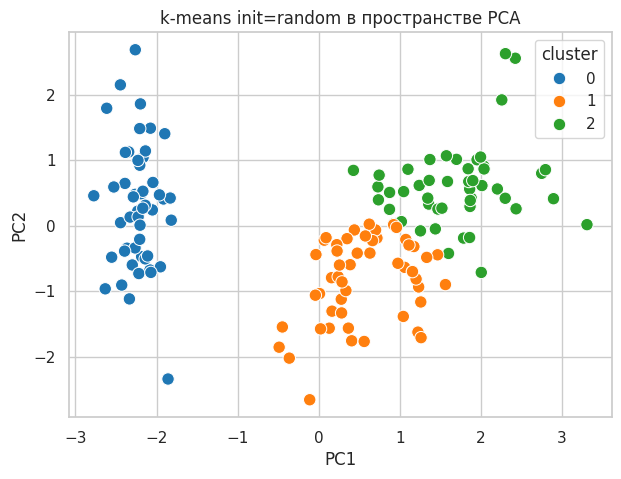

k-means++
Количество кластеров: 3
Adjusted Rand Index: 0.62
Silhouette score: 0.46


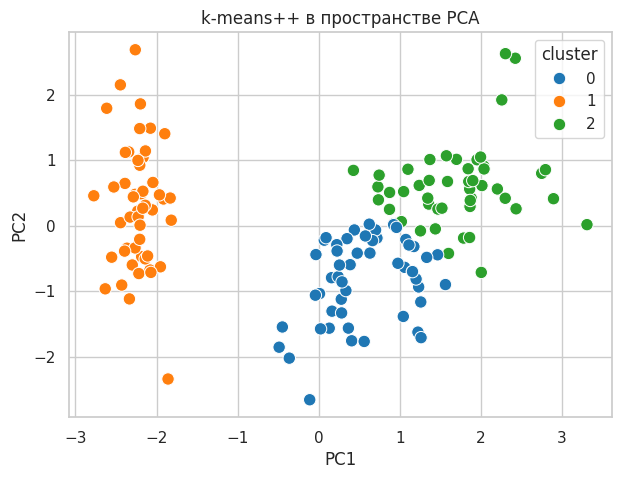

In [15]:
def evaluate_clusters(labels):
    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})
    print("Количество кластеров:", n_clusters)
    print("Adjusted Rand Index:", round(adjusted_rand_score(y_true, labels), 3))
    if n_clusters > 1:
        mask = labels != -1
        print("Silhouette score:", round(silhouette_score(X_scaled[mask], labels[mask]), 3))

def plot_clusters(labels, title):
    plot_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "cluster": labels})
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=80)
    plt.title(title)
    plt.show()

print("k-means")
evaluate_clusters(labels_random)
plot_clusters(labels_random, "k-means init=random в пространстве PCA")

print("k-means++")
evaluate_clusters(labels_plus)
plot_clusters(labels_plus, "k-means++ в пространстве PCA")


## Вывод

Входные данные соответствуют задаче кластеризации: используется датасет `Iris` размером `150 x 6`, в кластеризацию передаются `4` числовых признака, а `target` используется только для внешней оценки качества через `Adjusted Rand Index`. Перед обучением признаки стандартизированы.

Обе версии KMeans строились с `n_clusters = 3`, что соответствует числу известных видов Iris. По текущему запуску `k-means` с `init='random'` получил `Inertia = 139.825`, `Adjusted Rand Index = 0.610`, `Silhouette score = 0.459`. Версия `k-means++` получила `Inertia = 139.820`, `Adjusted Rand Index = 0.620`, `Silhouette score = 0.460`.

Обе инициализации дали почти одинаковое качество и выделили `3` кластера. `k-means++` в этом запуске немного лучше по всем трём числовым показателям, но разница минимальна. По сохранённым outputs нельзя делать вывод о скорости или стабильности, потому что время работы, число итераций и серия повторных запусков не оценивались.
